# 人力资源数据可视化看板

**数据来源**：《Excel数据可视化——从图表到数据大屏》第四章 人力资源看板素材（1470 名员工）

**分析维度**：总人数与结构概览、性别比例、年龄分布、学历分布、婚姻状况、部门分布、本月入/转/调动态

**对应 Excel 看板**：用 Python (pandas + matplotlib) 复现并扩展。

In [1]:
# 通用设置：路径、中文字体
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 中文字体（Windows 自带微软雅黑）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline

# 定位项目 data 目录（notebook 位于 notebooks/ 下）
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
DATA = ROOT / 'data'

# Excel 风格配色
COLORS = ['#4472C4', '#ED7D31', '#A5A5A5', '#FFC000', '#5B9BD5', '#70AD47']
print('数据目录:', DATA)


数据目录: C:\agent开发项目\大数据分析及数据可视化\data


## 1. 数据加载与清洗

In [2]:
# 读取员工基础信息（原表第 8 列之后是 Excel 看板的辅助统计区，只取前 8 列）
df = pd.read_excel(DATA / '人力资源数据.xlsx')
df = df.iloc[:, :8].dropna(subset=['员工编号']).copy()
df['员工编号'] = df['员工编号'].astype('int64')

# “本月入转调”为空表示本月无变动
df['本月入转调'] = df['本月入转调'].fillna('无变动')

print('数据形状:', df.shape)
df.head()

数据形状: (1470, 8)


,员工编号,年龄,性别,学历,婚姻状况,部门,本月入转调,年龄段
0,80010030,41,女,专科,单身,销售部,入职,40=<
1,80004349,49,男,专科以下,已婚,研发部,无变动,40=<
2,80002344,37,男,专科,单身,研发部,无变动,35-39
3,80001588,33,女,硕士研究生,已婚,研发部,无变动,30-34
4,80009001,27,男,专科以下,已婚,研发部,无变动,25-29


## 2. 核心指标（KPI）

In [3]:
total = len(df)
male = (df['性别'] == '男').sum()
female = (df['性别'] == '女').sum()
avg_age = df['年龄'].mean()
new_hire = (df['本月入转调'] == '入职').sum()

print(f'在册员工总数 : {total} 人')
print(f'男 / 女      : {male} 人 / {female} 人（男性占比 {male/total:.1%}）')
print(f'平均年龄     : {avg_age:.1f} 岁')
print(f'本月新入职   : {new_hire} 人')
print(f'本月转入/转出: {(df["本月入转调"]=="转入").sum()} 人 / {(df["本月入转调"]=="转出").sum()} 人')

在册员工总数 : 1470 人
男 / 女      : 882 人 / 588 人（男性占比 60.0%）
平均年龄     : 36.9 岁
本月新入职   : 40 人
本月转入/转出: 5 人 / 5 人


## 3. 六维结构看板

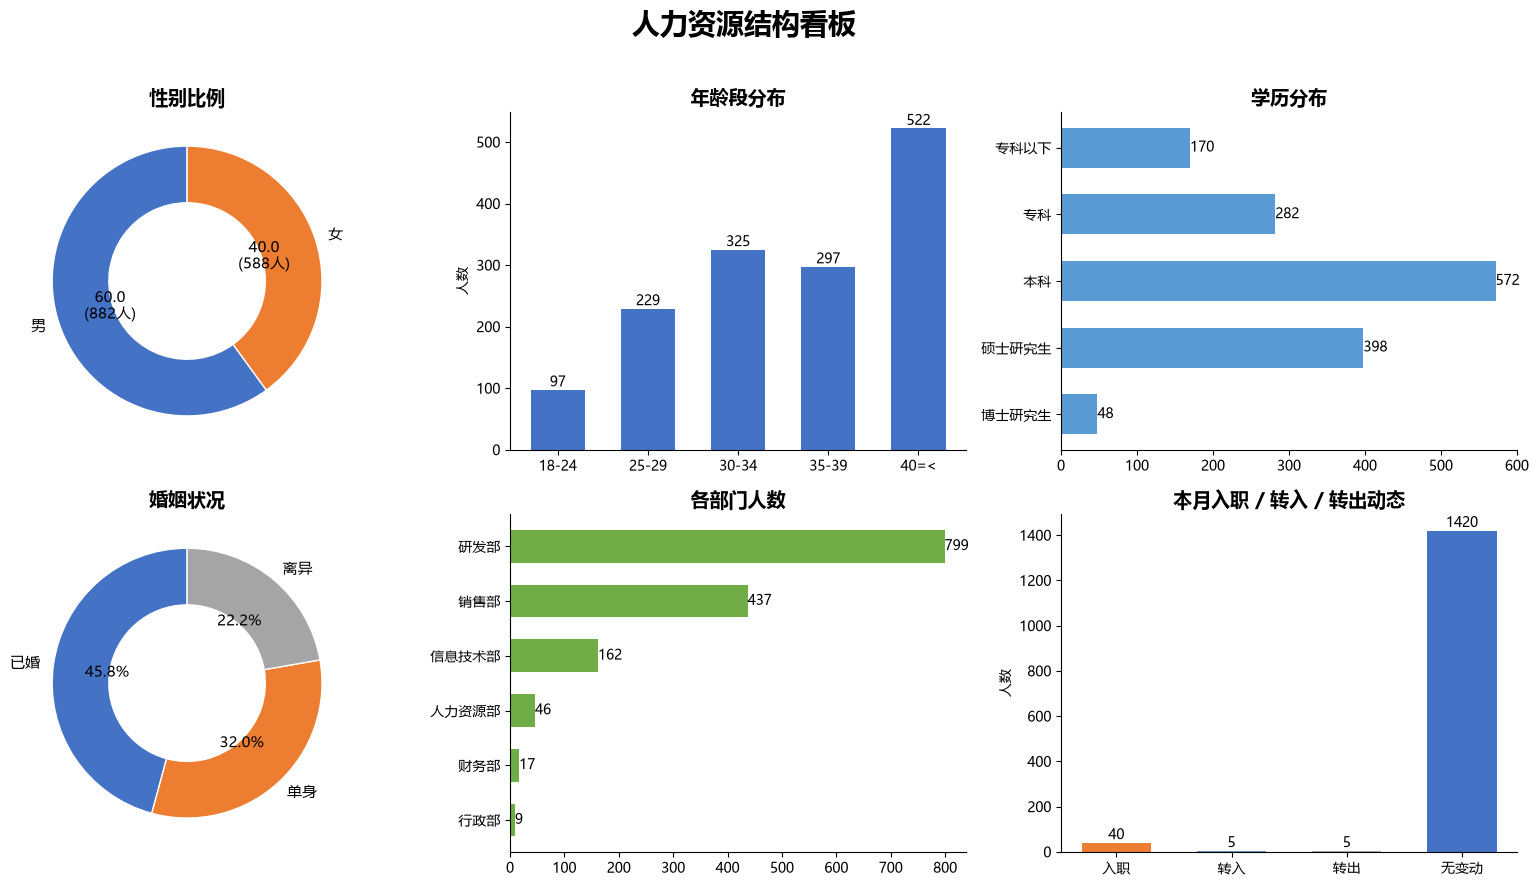

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('人力资源结构看板', fontsize=20, fontweight='bold', y=0.98)

# (1) 性别比例 —— 圆环图
ax = axes[0, 0]
g = df['性别'].value_counts()
ax.pie(g.values, labels=g.index, autopct=lambda p: f'{p:.1f}\n({p*total/100:.0f}人)',
       colors=[COLORS[0], COLORS[1]], startangle=90,
       wedgeprops=dict(width=0.42, edgecolor='w'), textprops={'fontsize': 11})
ax.set_title('性别比例', fontsize=14, fontweight='bold')

# (2) 年龄段分布 —— 柱形图
ax = axes[0, 1]
age_order = ['18-24', '25-29', '30-34', '35-39', '40=<']
g = df['年龄段'].value_counts().reindex(age_order)
bars = ax.bar(g.index, g.values, color=COLORS[0], width=0.6)
ax.bar_label(bars, fontsize=10)
ax.set_title('年龄段分布', fontsize=14, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylabel('人数')

# (3) 学历分布 —— 条形图（按学历高低排序）
ax = axes[0, 2]
edu_order = ['专科以下', '专科', '本科', '硕士研究生', '博士研究生']
g = df['学历'].value_counts().reindex(edu_order)
bars = ax.barh(g.index, g.values, color=COLORS[4], height=0.6)
ax.bar_label(bars, fontsize=10)
ax.set_title('学历分布', fontsize=14, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.invert_yaxis()

# (4) 婚姻状况 —— 圆环图
ax = axes[1, 0]
g = df['婚姻状况'].value_counts()
ax.pie(g.values, labels=g.index, autopct='%1.1f%%',
       colors=COLORS[:3], startangle=90,
       wedgeprops=dict(width=0.42, edgecolor='w'), textprops={'fontsize': 11})
ax.set_title('婚姻状况', fontsize=14, fontweight='bold')

# (5) 部门人数 —— 条形图
ax = axes[1, 1]
g = df['部门'].value_counts()
bars = ax.barh(g.index, g.values, color=COLORS[5], height=0.6)
ax.bar_label(bars, fontsize=10)
ax.set_title('各部门人数', fontsize=14, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.invert_yaxis()

# (6) 本月入转调 —— 柱形图
ax = axes[1, 2]
g = df['本月入转调'].value_counts().reindex(['入职', '转入', '转出', '无变动'])
bars = ax.bar(g.index, g.values, color=[COLORS[1], COLORS[4], COLORS[2], COLORS[0]], width=0.6)
ax.bar_label(bars, fontsize=10)
ax.set_title('本月入职 / 转入 / 转出动态', fontsize=14, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylabel('人数')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 4. 扩展分析：各部门性别构成

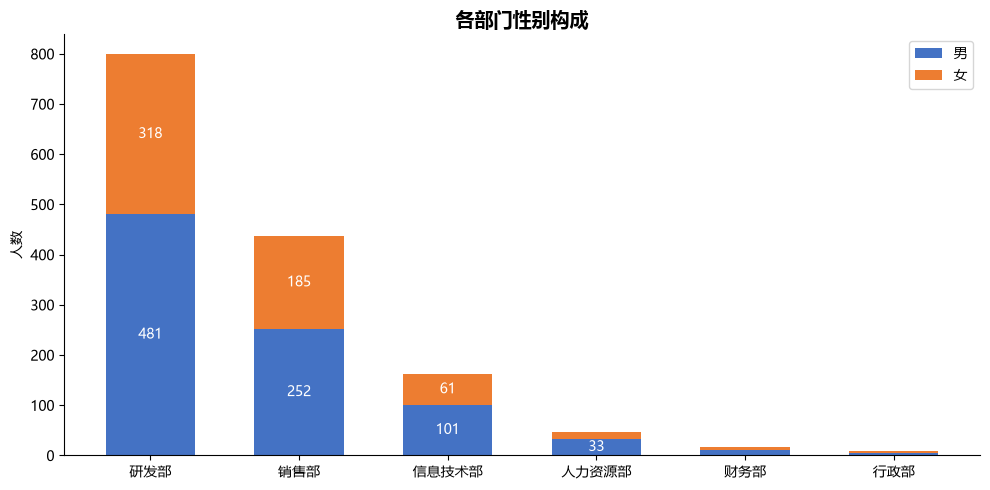

In [5]:
# 部门 × 性别 堆叠柱形
ct = pd.crosstab(df['部门'], df['性别']).reindex(df['部门'].value_counts().index)

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(ct))
for i, col in enumerate(['男', '女']):
    vals = ct[col].values
    bars = ax.bar(ct.index, vals, bottom=bottom, label=col, color=COLORS[i], width=0.6)
    for b, v in zip(bars, vals):
        if v > 30:
            ax.text(b.get_x() + b.get_width()/2, b.get_y() + v/2, str(v),
                    ha='center', va='center', fontsize=10, color='white')
    bottom += vals
ax.set_title('各部门性别构成', fontsize=14, fontweight='bold')
ax.set_ylabel('人数')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 5. 分析结论

1. **团队以中青年为主**：30 岁及以上员工占比超过 77%（其中 40 岁以上 522 人，占 35.5%），18-24 岁仅 97 人，团队偏成熟，可关注年轻梯队储备。
2. **性别结构**：男性 882 人（60%）、女性 588 人（40%），男女比约 3:2；研发、销售等大部门男性占比更高。
3. **学历水平较高**：本科及以上 1018 人，占 69.3%（硕士 398、博士 48），人员素质结构良好。
4. **部门分布不均**：研发部 799 人（54%）+ 销售部 437 人（30%）合计占 84%，是核心人力所在；行政部仅 9 人。
5. **本月动态**：新入职 40 人、转入/转出各 5 人，人员净流入 40 人，团队处于扩张状态。